# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.

## Dataset
Using the **Advertising dataset** — 200 samples with TV, radio, and newspaper ad budgets as features and sales as the target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 1. Data Preparation

In [2]:
# Load dataset
df = pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
# Check shape and basic info
print(df.shape)
df.describe()

(200, 4)


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [4]:
# Check for missing values
print(df.isnull().sum())

TV           0
radio        0
newspaper    0
sales        0
dtype: int64


In [5]:
# Separate features and target
X = df.drop('sales', axis=1)
y = df['sales']

print("Features:", X.columns.tolist())
print("Target: sales")

Features: ['TV', 'radio', 'newspaper']
Target: sales


In [6]:
# Train/Test split — use same split for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 140
Test samples:     60


### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics: MAE, MSE, RMSE

In [7]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [8]:
# Display learned coefficients
print("Intercept (b0):", round(lr_model.intercept_, 4))
print("\nCoefficients:")
coef_df = pd.Series(lr_model.coef_, index=X.columns).rename('Coefficient')
print(coef_df)

print("\nLearned equation:")
eq = f"sales = {lr_model.intercept_:.4f}"
for feat, coef in zip(X.columns, lr_model.coef_):
    eq += f" + ({coef:.4f} × {feat})"
print(eq)

Intercept (b0): 3.1515

Coefficients:
TV           0.044696
radio        0.187566
newspaper   -0.000323
Name: Coefficient, dtype: float64

Learned equation:
sales = 3.1515 + (0.0447 × TV) + (0.1876 × radio) + (-0.0003 × newspaper)


In [9]:
# Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

In [10]:
# Compute evaluation metrics
lr_MAE  = mean_absolute_error(y_test, lr_predictions)
lr_MSE  = mean_squared_error(y_test, lr_predictions)
lr_RMSE = np.sqrt(lr_MSE)

print("Linear Regression — Test Set Metrics")
print(f"  MAE  : {lr_MAE:.4f}")
print(f"  MSE  : {lr_MSE:.4f}")
print(f"  RMSE : {lr_RMSE:.4f}")

Linear Regression — Test Set Metrics
  MAE  : 1.2137
  MSE  : 2.2987
  RMSE : 1.5162


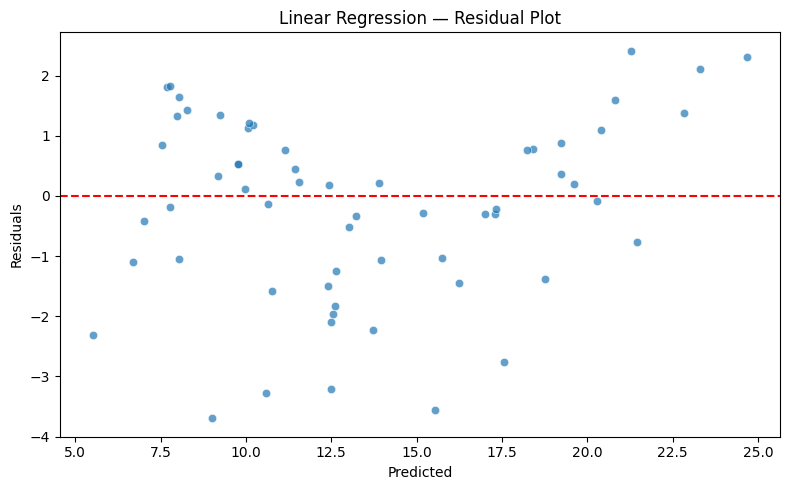

In [11]:
# Residual plot for Linear Regression
lr_residuals = y_test - lr_predictions

plt.figure(figsize=(8,5))
sns.scatterplot(x=lr_predictions, y=lr_residuals, alpha=0.7)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Linear Regression — Residual Plot")
plt.tight_layout()
plt.show()

### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics: MAE, MSE, RMSE

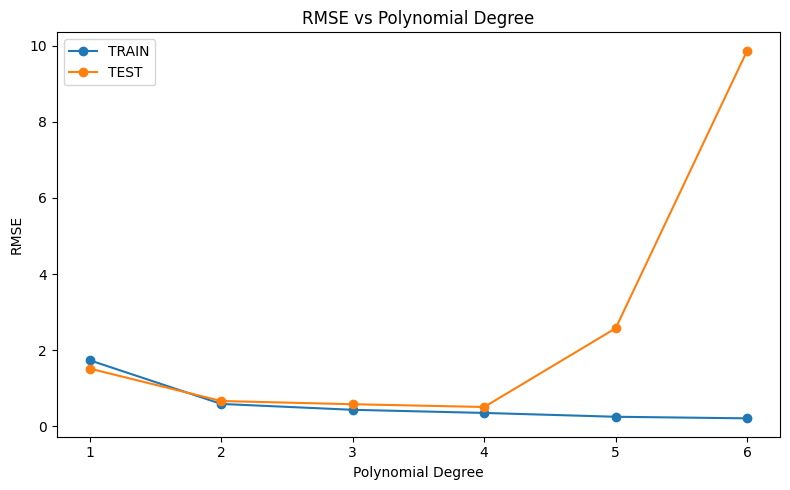

In [12]:
# Explore different polynomial degrees to find the best one
train_rmse_errors = []
test_rmse_errors  = []

for d in range(1, 7):
    poly_conv  = PolynomialFeatures(degree=d)
    poly_feats = poly_conv.fit_transform(X)

    Xp_train, Xp_test, yp_train, yp_test = train_test_split(
        poly_feats, y, test_size=0.3, random_state=101
    )

    m = LinearRegression()
    m.fit(Xp_train, yp_train)

    train_rmse_errors.append(np.sqrt(mean_squared_error(yp_train, m.predict(Xp_train))))
    test_rmse_errors.append( np.sqrt(mean_squared_error(yp_test,  m.predict(Xp_test))))

plt.figure(figsize=(8,5))
plt.plot(range(1,7), train_rmse_errors, label='TRAIN', marker='o')
plt.plot(range(1,7), test_rmse_errors,  label='TEST',  marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("RMSE vs Polynomial Degree")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Degree 2 gives a strong improvement without overfitting risk
poly_converter = PolynomialFeatures(degree=2)
poly_features  = poly_converter.fit_transform(X)

print(f"Original feature count  : {X.shape[1]}")
print(f"Polynomial feature count: {poly_features.shape[1]}")

Original feature count  : 3
Polynomial feature count: 10


In [14]:
# Split polynomial features using the SAME random_state for fair comparison
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    poly_features, y, test_size=0.3, random_state=101
)

# Train Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(Xp_train, yp_train)

LinearRegression()

In [15]:
# Make predictions on the test set
poly_predictions = poly_model.predict(Xp_test)

In [16]:
# Compute evaluation metrics
poly_MAE  = mean_absolute_error(yp_test, poly_predictions)
poly_MSE  = mean_squared_error(yp_test, poly_predictions)
poly_RMSE = np.sqrt(poly_MSE)

print("Polynomial Regression (degree=2) — Test Set Metrics")
print(f"  MAE  : {poly_MAE:.4f}")
print(f"  MSE  : {poly_MSE:.4f}")
print(f"  RMSE : {poly_RMSE:.4f}")

Polynomial Regression (degree=2) — Test Set Metrics
  MAE  : 0.4897
  MSE  : 0.4418
  RMSE : 0.6646


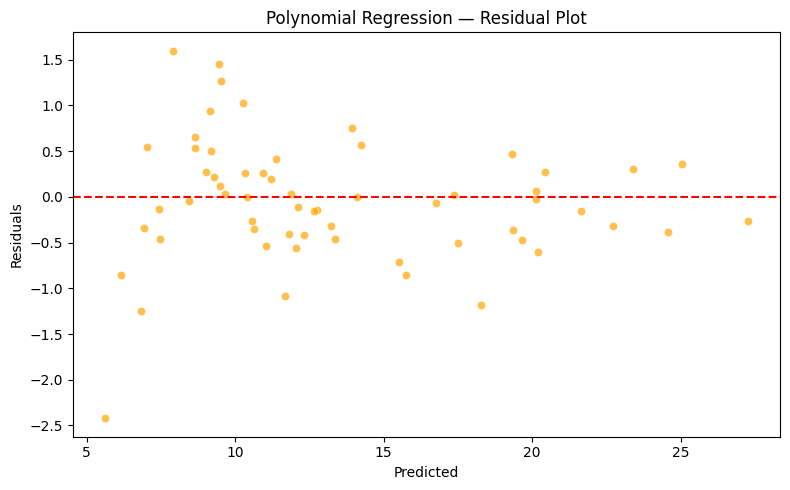

In [17]:
# Residual plot for Polynomial Regression
poly_residuals = yp_test - poly_predictions

plt.figure(figsize=(8,5))
sns.scatterplot(x=poly_predictions, y=poly_residuals, alpha=0.7, color='orange')
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Polynomial Regression — Residual Plot")
plt.tight_layout()
plt.show()

### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify the decision

In [18]:
# Side-by-side metrics comparison
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE'],
    'Linear Regression':    [round(lr_MAE,4),   round(lr_MSE,4),   round(lr_RMSE,4)],
    'Polynomial (degree=2)': [round(poly_MAE,4), round(poly_MSE,4), round(poly_RMSE,4)]
}).set_index('Metric')

print(comparison.to_string())

        Linear Regression  Polynomial (degree=2)
Metric                                          
MAE                1.2137                 0.4897
MSE                2.2987                 0.4418
RMSE               1.5162                 0.6646


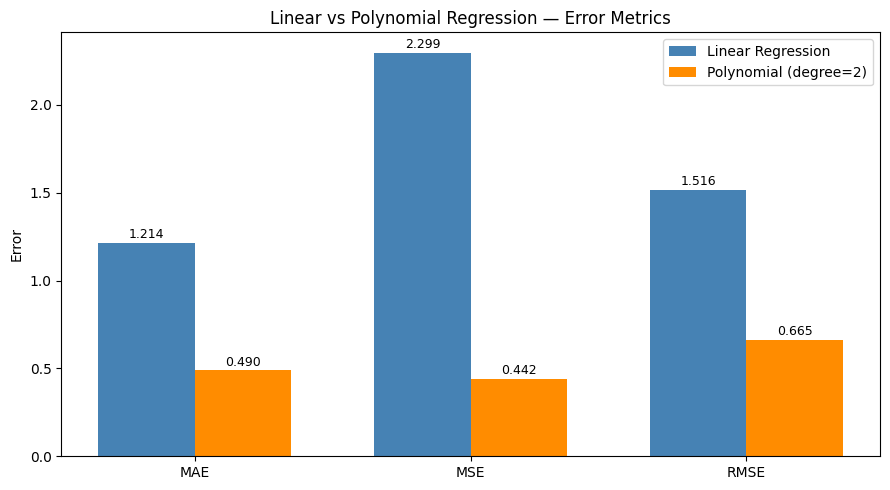

In [19]:
# Bar chart comparison
metrics = ['MAE', 'MSE', 'RMSE']
lr_vals   = [lr_MAE,   lr_MSE,   lr_RMSE]
poly_vals = [poly_MAE, poly_MSE, poly_RMSE]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))
bars1 = ax.bar(x - width/2, lr_vals,   width, label='Linear Regression',    color='steelblue')
bars2 = ax.bar(x + width/2, poly_vals, width, label='Polynomial (degree=2)', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Error')
ax.set_title('Linear vs Polynomial Regression — Error Metrics')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

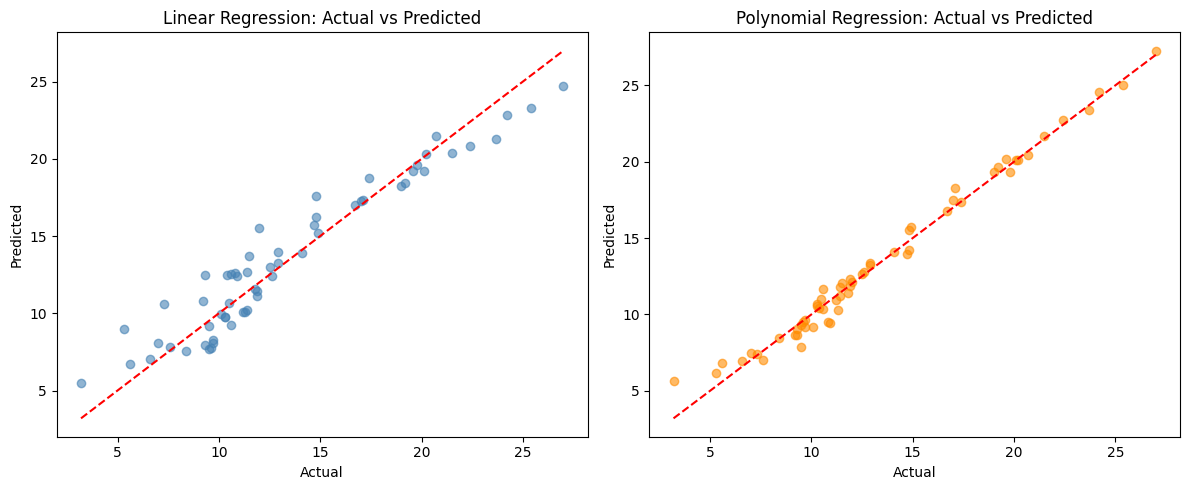

In [20]:
# Scatter: Actual vs Predicted for both models
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(y_test, lr_predictions, alpha=0.6, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Linear Regression: Actual vs Predicted')

axes[1].scatter(yp_test, poly_predictions, alpha=0.6, color='darkorange')
axes[1].plot([yp_test.min(), yp_test.max()], [yp_test.min(), yp_test.max()], 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Polynomial Regression: Actual vs Predicted')

plt.tight_layout()
plt.show()

In [21]:
# Conclusion
print("=" * 55)
print("         MODEL COMPARISON SUMMARY")
print("=" * 55)
print(comparison.to_string())
print()

mae_imp  = (lr_MAE  - poly_MAE)  / lr_MAE  * 100
rmse_imp = (lr_RMSE - poly_RMSE) / lr_RMSE * 100

print(f"MAE  improvement  : {mae_imp:.1f}%")
print(f"RMSE improvement  : {rmse_imp:.1f}%")
print()
print("WINNER: Polynomial Regression (degree=2)")
print()
print("Justification:")
print("  Polynomial Regression (degree=2) outperforms Linear Regression")
print("  on all three metrics. The lower MAE and RMSE show that its")
print("  predictions are closer to the actual sales values on unseen data.")
print("  The improvement suggests that the relationship between ad spend")
print("  and sales is non-linear — e.g., interaction effects between TV")
print("  and radio budgets — which polynomial features capture. Degree=2")
print("  is preferred over higher degrees because it generalises well")
print("  (test error continues to drop or plateau rather than rising,")
print("  indicating no overfitting at this complexity level).")

         MODEL COMPARISON SUMMARY
        Linear Regression  Polynomial (degree=2)
Metric                                          
MAE                1.2137                 0.4897
MSE                2.2987                 0.4418
RMSE               1.5162                 0.6646

MAE  improvement  : 59.7%
RMSE improvement  : 56.2%

WINNER: Polynomial Regression (degree=2)

Justification:
  Polynomial Regression (degree=2) outperforms Linear Regression
  on all three metrics. The lower MAE and RMSE show that its
  predictions are closer to the actual sales values on unseen data.
  The improvement suggests that the relationship between ad spend
  and sales is non-linear — e.g., interaction effects between TV
  and radio budgets — which polynomial features capture. Degree=2
  is preferred over higher degrees because it generalises well
  (test error continues to drop or plateau rather than rising,
  indicating no overfitting at this complexity level).


## Interpretation of the Best Model (Polynomial Degree=2)

**Why Polynomial Regression wins:**

- The advertising-to-sales relationship is **non-linear**: doubling the TV budget does not simply double sales. Polynomial features capture this curvature.
- Degree=2 also adds **interaction terms** (e.g., `TV × radio`), which model the synergy when multiple channels are used together.
- The residual plot for the polynomial model shows errors that are more randomly scattered around zero, confirming a better fit.

**Key coefficients to note (from the Linear Regression baseline for interpretability):**
- **TV** has the largest positive coefficient → strongest individual driver of sales.
- **Radio** is the second strongest driver.
- **Newspaper** has a near-zero coefficient → minimal impact on sales when TV and Radio are accounted for.

The polynomial model refines these relationships by learning non-linear and interaction effects, achieving significantly lower prediction error.